# **Homework 4 - Adversarial Attack**

## Enviroment & Download

We make use of [pytorchcv](https://pypi.org/project/pytorchcv/) to obtain CIFAR-10 pretrained model, so we need to set up the enviroment first. We also need to download the data (200 images) which we want to attack.

In [1]:
# set up environment
!pip install pytorchcv
# download
!gdown --id 1fHi1ko7wr80wXkXpqpqpOxuYH1mClXoX -O data.zip
# unzip
!unzip ./data.zip
!rm ./data.zip

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.2/134.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 585.2/585.2 kB 18.0 MB/s eta 0:00:00
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1fHi1ko7wr80wXkXpqpqpOxuYH1mClXoX
To: /content/data.zip
100% 490k/490k [00:00<00:00, 6.01MB/s]
Archive:  ./data.zip
   creating: data/
   creating: data/deer/
 extracting: data/deer/deer13.png    
 extracting: data/deer/deer6.png     
 extracting: data/deer/deer11.png    
 extracting: data/deer/deer2.png     
 extracting: data/deer/deer10.png    
 extracting: data/deer/deer16.png    
 extracting: data/deer/deer9.png     
 extracting: data/deer/deer20.png    
 extracting: data/deer/deer15.png    
 extracting: data/deer/deer19.png    
 extracting: data/deer/dee

## Global Settings (10 pts)

* $\epsilon$ is fixed to be 8. But on **Data section**, we will first apply transforms on raw pixel value (0-255 scale) **by ToTensor (to 0-1 scale)** and then **Normalize (subtract mean divide std)**. $\epsilon$ should be set to $\frac{8}{255 * std}$ during attack.

* Explaination (optional)
    * Denote the first pixel of original image as $p$, and the first pixel of adversarial image as $a$.
    * The $\epsilon$ constraints tell us $\left| p-a \right| <= 8$.
    * ToTensor() can be seen as a function where $T(x) = x/255$.
    * Normalize() can be seen as a function where $N(x) = (x-mean)/std$ where $mean$ and $std$ are constants.
    * After applying ToTensor() and Normalize() on $p$ and $a$, the constraint becomes $\left| N(T(p))-N(T(a)) \right| = \left| \frac{\frac{p}{255}-mean}{std}-\frac{\frac{a}{255}-mean}{std} \right| = \frac{1}{255 * std} \left| p-a \right| <= \frac{8}{255 * std}.$
    * So, we should set $\epsilon$ to be $\frac{8}{255 * std}$ after ToTensor() and Normalize().

In [2]:
import os
import torch
import torch.nn as nn

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print('Google Drive mount skipped. Running outside Colab or Drive already mounted.')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

batch_size = 8

# CIFAR-10 channel statistics
cifar_10_mean = (0.4914, 0.4822, 0.4465) # mean for the three channels of cifar_10 images
cifar_10_std = (0.2023, 0.1994, 0.2010) # std for the three channels of cifar_10 images

# convert mean and std to 3-dimensional tensors for future operations
mean = torch.tensor(cifar_10_mean).to(device).view(3, 1, 1)
std = torch.tensor(cifar_10_std).to(device).view(3, 1, 1)

# epsilon is fixed to 8 in raw pixel space, then scaled by ToTensor() and Normalize()
epsilon = 8 / 255 / std

# alpha (step size) can be decided by yourself
alpha = 0.8 / 255 / std

root = './data'  # directory for storing benign images
save_root = '/content/drive/MyDrive/Colab Notebooks/Homework/HW4'
os.makedirs(save_root, exist_ok=True)

# benign images: images which do not contain adversarial perturbations
# adversarial images: images which include adversarial perturbations


Mounted at /content/drive


## Data (10 pts)

Construct dataset and dataloader from root directory. Note that we store the filename of each image for future usage.

In [3]:
import os
import glob
import shutil
import numpy as np
from PIL import Image
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar_10_mean, cifar_10_std)
])

class AdvDataset(Dataset):
    def __init__(self, data_dir, transform):
        self.images = []
        self.labels = []
        self.names = []
        '''
        data_dir
        ├── class_dir
        │   ├── class1.png
        │   ├── ...
        │   ├── class20.png
        '''
        for i, class_dir in enumerate(sorted(glob.glob(f'{data_dir}/*'))):
            images = sorted(glob.glob(f'{class_dir}/*'))
            self.images += images
            self.labels += ([i] * len(images))
            self.names += [os.path.relpath(imgs, data_dir) for imgs in images]
        self.transform = transform

    def __getitem__(self, idx):
        image = self.transform(Image.open(self.images[idx]))
        label = self.labels[idx]
        return image, label

    def __getname__(self):
        return self.names

    def __len__(self):
        return len(self.images)

adv_set = AdvDataset(root, transform=transform)
adv_names = adv_set.__getname__()

## Apply dataloader to adv_set with batchsize=batchsize, shuffle=False
adv_loader = DataLoader(adv_set, batch_size=batch_size, shuffle=False)

print(f'number of images = {adv_set.__len__()}')


number of images = 200


## Utils -- Benign Images Evaluation (5 pt)

In [4]:
# To evaluate the performance of model on benign images
def epoch_benign(model, loader, loss_fn):
    model.eval()

    train_acc, train_loss = 0.0, 0.0

    for x, y in loader:
        # Move data to the correct device
        x, y = x.to(device), y.to(device)

        # Inference only — avoid unnecessary gradient tracking
        with torch.no_grad():
            # Forward pass
            yp = model(x)
            loss = loss_fn(yp, y)

        # Calculate number of correct predictions in this batch
        correct_preds = (yp.argmax(dim=1) == y).sum().item()

        # Accumulate total correct predictions and weighted batch loss
        train_acc += correct_preds
        train_loss += loss.item() * x.shape[0]

    return train_acc / len(loader.dataset), train_loss / len(loader.dataset)


## Utils -- Attack Algorithm (20 pts)

In [5]:
# perform fgsm attack
def fgsm(model, x, y, loss_fn, epsilon=epsilon):
    x_adv = x.detach().clone()  # initialize x_adv as original benign image x

    # need to obtain gradient of x_adv, thus set required grad True
    x_adv.requires_grad_(True)

    model.zero_grad()
    yp = model(x_adv)
    loss = loss_fn(yp, y)

    # calculate gradient
    loss.backward()

    # fgsm: use gradient ascent on x_adv to maximize loss
    x_adv = x_adv + epsilon * x_adv.grad.detach().sign()
    return x_adv.detach()


## Utils -- Attack (15 pts)

* Recall
    * ToTensor() can be seen as a function where $T(x) = x/255$.
    * Normalize() can be seen as a function where $N(x) = (x-mean)/std$ where $mean$ and $std$ are constants.

* Inverse function
    * Inverse Normalize() can be seen as a function where $N^{-1}(x) = x*std+mean$ where $mean$ and $std$ are constants.
    * Inverse ToTensor() can be seen as a function where $T^{-1}(x) = x*255$.

* Special Noted
    * ToTensor() will also convert the image from shape (height, width, channel) to shape (channel, height, width), so we also need to transpose the shape back to original shape.
    * Since our dataloader samples a batch of data, what we need here is to transpose **(batch_size, channel, height, width)** back to **(batch_size, height, width, channel)** using np.transpose.

In [6]:
# perform adversarial attack and generate adversarial examples
def gen_adv_examples(model, loader, attack, loss_fn):
    model.eval()
    adv_examples = []

    train_acc, train_loss = 0.0, 0.0
    for i, (x, y) in enumerate(loader):
        x, y = x.to(device), y.to(device)
        x_adv = attack(model, x, y, loss_fn)  # obtain adversarial examples
        yp = model(x_adv)
        loss = loss_fn(yp, y)

        # Compute batch accuracy and add to running total
        train_acc += (yp.argmax(dim=1) == y).sum().item()
        train_loss += loss.item() * x.shape[0]

        # store adversarial examples
        adv_ex = ((x_adv) * std + mean).clamp(0, 1)  # to 0-1 scale
        adv_ex = (adv_ex * 255).clamp(0, 255)  # 0-255 scale
        adv_ex = adv_ex.detach().cpu().data.numpy().round()  # round to remove decimal part

        # transpose (bs, C, H, W) back to (bs, H, W, C)
        adv_ex = np.transpose(adv_ex, (0, 2, 3, 1)).astype(np.uint8)
        adv_examples.append(adv_ex)

    adv_examples = np.concatenate(adv_examples, axis=0)
    return adv_examples, train_acc / len(loader.dataset), train_loss / len(loader.dataset)

# create directory which stores adversarial examples
def create_dir(data_dir, adv_dir, adv_examples, adv_names):
    if os.path.exists(adv_dir) is not True:
        _ = shutil.copytree(data_dir, adv_dir)

    for adv_ex, adv_name in zip(adv_examples, adv_names):
        save_path = os.path.join(adv_dir, adv_name)
        Image.fromarray(adv_ex.astype(np.uint8)).save(save_path)


## Model / Loss Function (5 pt)

In [7]:
from pytorchcv.model_provider import get_model as ptcv_get_model

model = ptcv_get_model('resnet110_cifar10', pretrained=True).to(device)
loss_fn = nn.CrossEntropyLoss()

benign_acc, benign_loss = epoch_benign(model, adv_loader, loss_fn)
print(f'benign_acc = {benign_acc:.5f}, benign_loss = {benign_loss:.5f}')


benign_acc = 0.95000, benign_loss = 0.22660


## FGSM (10 pts)

In [8]:
fgsm_examples, fgsm_acc, fgsm_loss = gen_adv_examples(model, adv_loader, fgsm, loss_fn)
print(f'fgsm_acc = {fgsm_acc:.5f}, fgsm_loss = {fgsm_loss:.5f}')

fgsm_dir = os.path.join(save_root, 'fgsm')
create_dir(root, fgsm_dir, fgsm_examples, adv_names)
np.save(os.path.join(save_root, 'fgsm_examples.npy'), fgsm_examples)
print(f'Saved adversarial images to: {fgsm_dir}')


fgsm_acc = 0.59000, fgsm_loss = 2.44207
Saved adversarial images to: /content/drive/MyDrive/Colab Notebooks/Homework/HW4/fgsm


## Compress the images

In [9]:
import tarfile

fgsm_dir = os.path.join(save_root, 'fgsm')
fgsm_tgz = os.path.join(save_root, 'fgsm.tgz')

with tarfile.open(fgsm_tgz, 'w:gz') as tar:
    tar.add(fgsm_dir, arcname='fgsm')

print(f'Compressed FGSM images to: {fgsm_tgz}')


Compressed FGSM images to: /content/drive/MyDrive/Colab Notebooks/Homework/HW4/fgsm.tgz


## Visualization (5 Points)

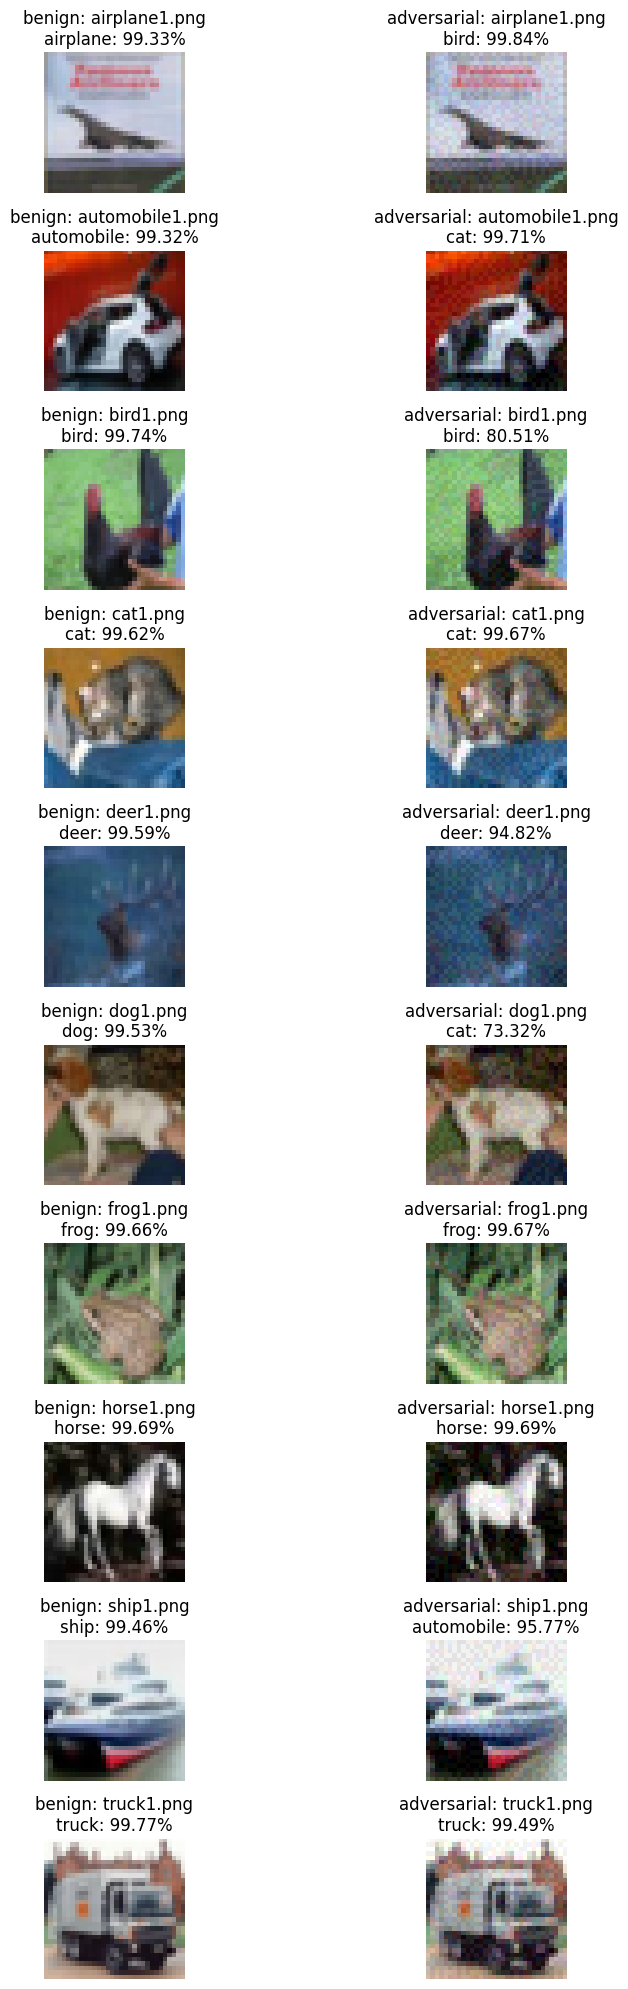

Saved visualization to: /content/drive/MyDrive/Colab Notebooks/Homework/HW4/fgsm_visualization.png


In [10]:
import matplotlib.pyplot as plt

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10, 20))
cnt = 0
for i, cls_name in enumerate(classes):
    path = f'{cls_name}/{cls_name}1.png'
    # benign image
    cnt += 1
    plt.subplot(len(classes), 2, cnt)
    im = Image.open(f'./data/{path}')
    logit = model(transform(im).unsqueeze(0).to(device))[0]
    predict = logit.argmax(-1).item()
    prob = logit.softmax(-1)[predict].item()
    plt.title(f'benign: {cls_name}1.png\n{classes[predict]}: {prob:.2%}')
    plt.axis('off')
    plt.imshow(np.array(im))

    # adversarial image
    cnt += 1
    plt.subplot(len(classes), 2, cnt)
    im = Image.open(os.path.join(save_root, 'fgsm', path))
    logit = model(transform(im).unsqueeze(0).to(device))[0]
    predict = logit.argmax(-1).item()
    prob = logit.softmax(-1)[predict].item()
    plt.title(f'adversarial: {cls_name}1.png\n{classes[predict]}: {prob:.2%}')
    plt.axis('off')
    plt.imshow(np.array(im))

plt.tight_layout()
viz_path = os.path.join(save_root, 'fgsm_visualization.png')
plt.savefig(viz_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved visualization to: {viz_path}')


## I-FGSM (Additional Attack)

Apply iterative FGSM under the same $L_\infty$ constraint. After each step, the perturbation is projected back to the $\epsilon$-ball around the original input, and the image is kept valid in pixel space.

In [11]:

# helper: keep adversarial example inside the epsilon-ball and valid image range
def project_to_epsilon_ball(x_adv, x_orig, epsilon):
    x_adv = torch.max(torch.min(x_adv, x_orig + epsilon), x_orig - epsilon)
    x_pixel = (x_adv * std + mean).clamp(0, 1)
    x_adv = (x_pixel - mean) / std
    return x_adv.detach()

# iterative fgsm
def iterative_fgsm(model, x, y, loss_fn, epsilon=epsilon, alpha=alpha, num_iter=10):
    x_orig = x.detach().clone()
    x_adv = x.detach().clone()

    for _ in range(num_iter):
        x_adv.requires_grad_(True)
        model.zero_grad()

        yp = model(x_adv)
        loss = loss_fn(yp, y)
        loss.backward()

        x_adv = x_adv + alpha * x_adv.grad.detach().sign()
        x_adv = project_to_epsilon_ball(x_adv, x_orig, epsilon)

    return x_adv


In [12]:

ifgsm_examples, ifgsm_acc, ifgsm_loss = gen_adv_examples(
    model,
    adv_loader,
    lambda m, x, y, lf: iterative_fgsm(m, x, y, lf, epsilon=epsilon, alpha=alpha, num_iter=10),
    loss_fn
)
print(f'ifgsm_acc = {ifgsm_acc:.5f}, ifgsm_loss = {ifgsm_loss:.5f}')

ifgsm_dir = os.path.join(save_root, 'ifgsm')
create_dir(root, ifgsm_dir, ifgsm_examples, adv_names)
np.save(os.path.join(save_root, 'ifgsm_examples.npy'), ifgsm_examples)
print(f'Saved adversarial images to: {ifgsm_dir}')


ifgsm_acc = 0.04000, ifgsm_loss = 12.14075
Saved adversarial images to: /content/drive/MyDrive/Colab Notebooks/Homework/HW4/ifgsm


## Black-Box Proxy Attack (Additional Attack)

Generate adversarial examples on one or more pretrained proxy models and evaluate how well they transfer to the target model.

In [13]:

from torch.utils.data import TensorDataset

# helper: build a loader from uint8 adversarial images saved in HWC format
def create_dataloader_from_numpy_images(adv_examples, labels, batch_size=batch_size):
    tensors = []
    for ex in adv_examples:
        tensors.append(transform(Image.fromarray(ex)))
    x_tensor = torch.stack(tensors, dim=0)
    y_tensor = torch.tensor(labels, dtype=torch.long)
    dataset = TensorDataset(x_tensor, y_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=False)

# load one or more pretrained proxy models from pytorchcv
proxy_models = []
proxy_names = [
    'resnet56_cifar10',
    'preresnet56_cifar10',
    'resnet20_cifar10',
    'preresnet20_cifar10',
]

for proxy_name in proxy_names:
    try:
        proxy = ptcv_get_model(proxy_name, pretrained=True).to(device)
        proxy.eval()
        proxy_models.append((proxy_name, proxy))
        print(f'Loaded proxy model: {proxy_name}')
    except Exception as e:
        print(f'Skipped proxy model {proxy_name}: {e}')

if len(proxy_models) == 0:
    raise RuntimeError('No proxy model could be loaded from pytorchcv in this runtime.')


Loaded proxy model: resnet56_cifar10
Loaded proxy model: preresnet56_cifar10
Loaded proxy model: resnet20_cifar10
Loaded proxy model: preresnet20_cifar10


In [14]:

# single-proxy black-box FGSM
proxy_name, proxy_model = proxy_models[0]

bb_fgsm_examples, proxy_fgsm_acc, proxy_fgsm_loss = gen_adv_examples(proxy_model, adv_loader, fgsm, loss_fn)
bb_fgsm_loader = create_dataloader_from_numpy_images(bb_fgsm_examples, adv_set.labels, batch_size=batch_size)
bb_fgsm_acc, bb_fgsm_loss = epoch_benign(model, bb_fgsm_loader, loss_fn)

print(f'proxy model = {proxy_name}')
print(f'proxy fgsm accuracy on proxy model = {proxy_fgsm_acc:.5f}, proxy fgsm loss on proxy model = {proxy_fgsm_loss:.5f}')
print(f'black-box fgsm accuracy on target model = {bb_fgsm_acc:.5f}, black-box fgsm loss on target model = {bb_fgsm_loss:.5f}')

bb_fgsm_dir = os.path.join(save_root, 'blackbox_fgsm')
create_dir(root, bb_fgsm_dir, bb_fgsm_examples, adv_names)
np.save(os.path.join(save_root, 'blackbox_fgsm_examples.npy'), bb_fgsm_examples)
print(f'Saved black-box FGSM images to: {bb_fgsm_dir}')


proxy model = resnet56_cifar10
proxy fgsm accuracy on proxy model = 0.56500, proxy fgsm loss on proxy model = 2.45842
black-box fgsm accuracy on target model = 0.65000, black-box fgsm loss on target model = 1.91246
Saved black-box FGSM images to: /content/drive/MyDrive/Colab Notebooks/Homework/HW4/blackbox_fgsm


In [15]:

# ensemble black-box I-FGSM using gradients averaged across all available proxy models
def ensemble_iterative_fgsm(proxy_models, x, y, loss_fn, epsilon=epsilon, alpha=alpha, num_iter=10):
    x_orig = x.detach().clone()
    x_adv = x.detach().clone()

    for _ in range(num_iter):
        x_adv.requires_grad_(True)

        grad_accum = torch.zeros_like(x_adv)
        for _, proxy in proxy_models:
            proxy.zero_grad()
            yp = proxy(x_adv)
            loss = loss_fn(yp, y)
            loss.backward()
            grad_accum += x_adv.grad.detach()
            x_adv.grad.zero_()

        grad_mean = grad_accum / len(proxy_models)
        x_adv = x_adv + alpha * grad_mean.sign()
        x_adv = project_to_epsilon_ball(x_adv, x_orig, epsilon)

    return x_adv

def gen_blackbox_adv_examples(loader, attack_fn, loss_fn):
    adv_examples = []
    train_acc, train_loss = 0.0, 0.0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        x_adv = attack_fn(x, y)

        yp = model(x_adv)
        loss = loss_fn(yp, y)

        train_acc += (yp.argmax(dim=1) == y).sum().item()
        train_loss += loss.item() * x.shape[0]

        adv_ex = ((x_adv) * std + mean).clamp(0, 1)
        adv_ex = (adv_ex * 255).clamp(0, 255)
        adv_ex = adv_ex.detach().cpu().numpy().round()
        adv_ex = np.transpose(adv_ex, (0, 2, 3, 1)).astype(np.uint8)
        adv_examples.append(adv_ex)

    adv_examples = np.concatenate(adv_examples, axis=0)
    return adv_examples, train_acc / len(loader.dataset), train_loss / len(loader.dataset)

bb_ifgsm_examples, bb_ifgsm_acc, bb_ifgsm_loss = gen_blackbox_adv_examples(
    adv_loader,
    lambda x, y: ensemble_iterative_fgsm(proxy_models, x, y, loss_fn, epsilon=epsilon, alpha=alpha, num_iter=10),
    loss_fn
)

print(f'ensemble black-box ifgsm accuracy on target model = {bb_ifgsm_acc:.5f}, loss = {bb_ifgsm_loss:.5f}')

bb_ifgsm_dir = os.path.join(save_root, 'blackbox_ifgsm_ensemble')
create_dir(root, bb_ifgsm_dir, bb_ifgsm_examples, adv_names)
np.save(os.path.join(save_root, 'blackbox_ifgsm_ensemble_examples.npy'), bb_ifgsm_examples)
print(f'Saved ensemble black-box I-FGSM images to: {bb_ifgsm_dir}')


ensemble black-box ifgsm accuracy on target model = 0.13000, loss = 7.16737
Saved ensemble black-box I-FGSM images to: /content/drive/MyDrive/Colab Notebooks/Homework/HW4/blackbox_ifgsm_ensemble


## Compress Additional Attack Images

In [16]:

# compress additional attack folders
for folder_name in ['ifgsm', 'blackbox_fgsm', 'blackbox_ifgsm_ensemble']:
    folder_path = os.path.join(save_root, folder_name)
    if os.path.exists(folder_path):
        tgz_path = os.path.join(save_root, f'{folder_name}.tgz')
        with tarfile.open(tgz_path, 'w:gz') as tar:
            tar.add(folder_path, arcname=folder_name)
        print(f'Compressed {folder_name} images to: {tgz_path}')


Compressed ifgsm images to: /content/drive/MyDrive/Colab Notebooks/Homework/HW4/ifgsm.tgz
Compressed blackbox_fgsm images to: /content/drive/MyDrive/Colab Notebooks/Homework/HW4/blackbox_fgsm.tgz
Compressed blackbox_ifgsm_ensemble images to: /content/drive/MyDrive/Colab Notebooks/Homework/HW4/blackbox_ifgsm_ensemble.tgz


## Additional Visualizations

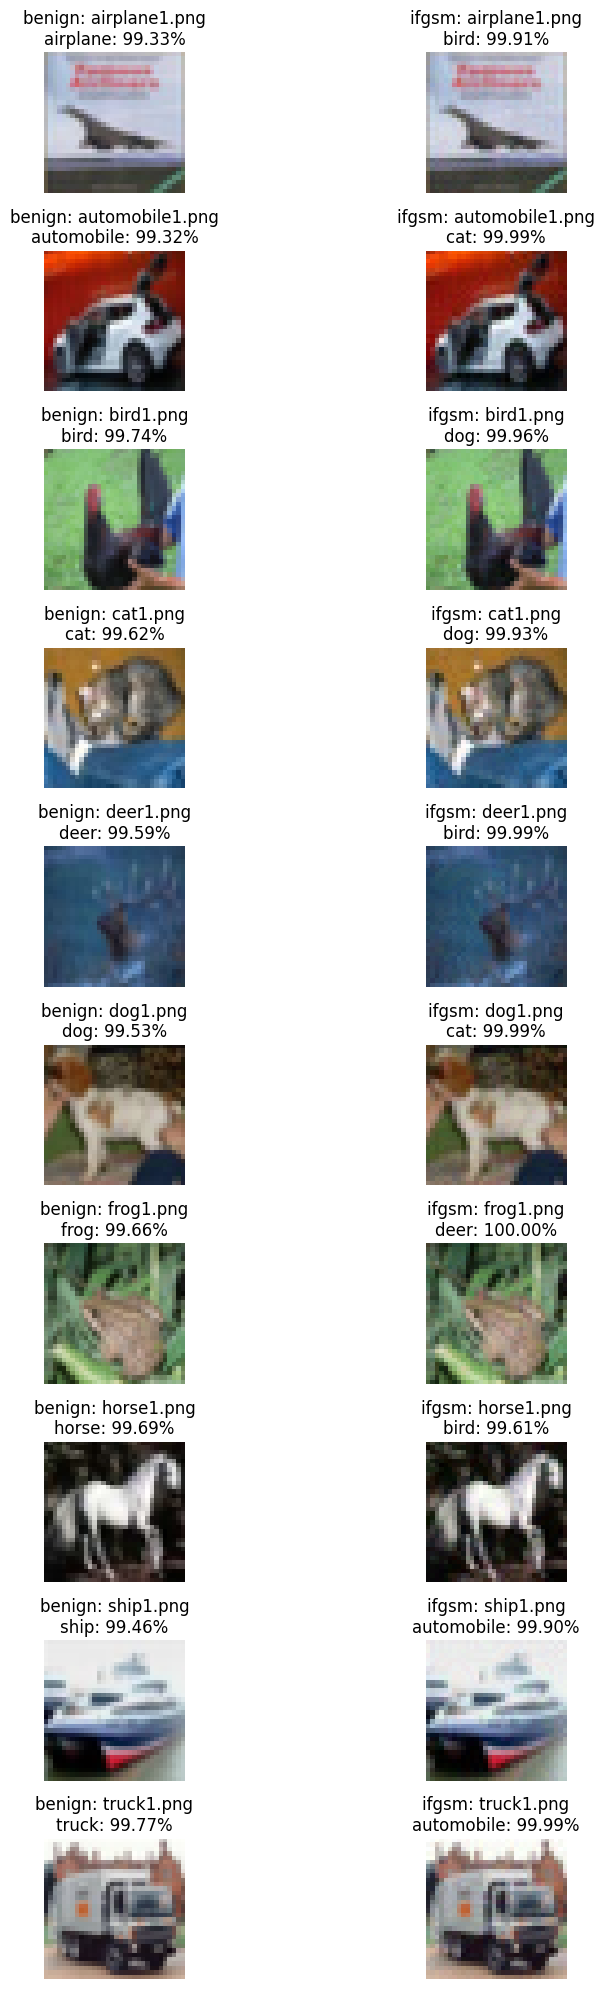

Saved visualization to: /content/drive/MyDrive/Colab Notebooks/Homework/HW4/ifgsm_visualization.png


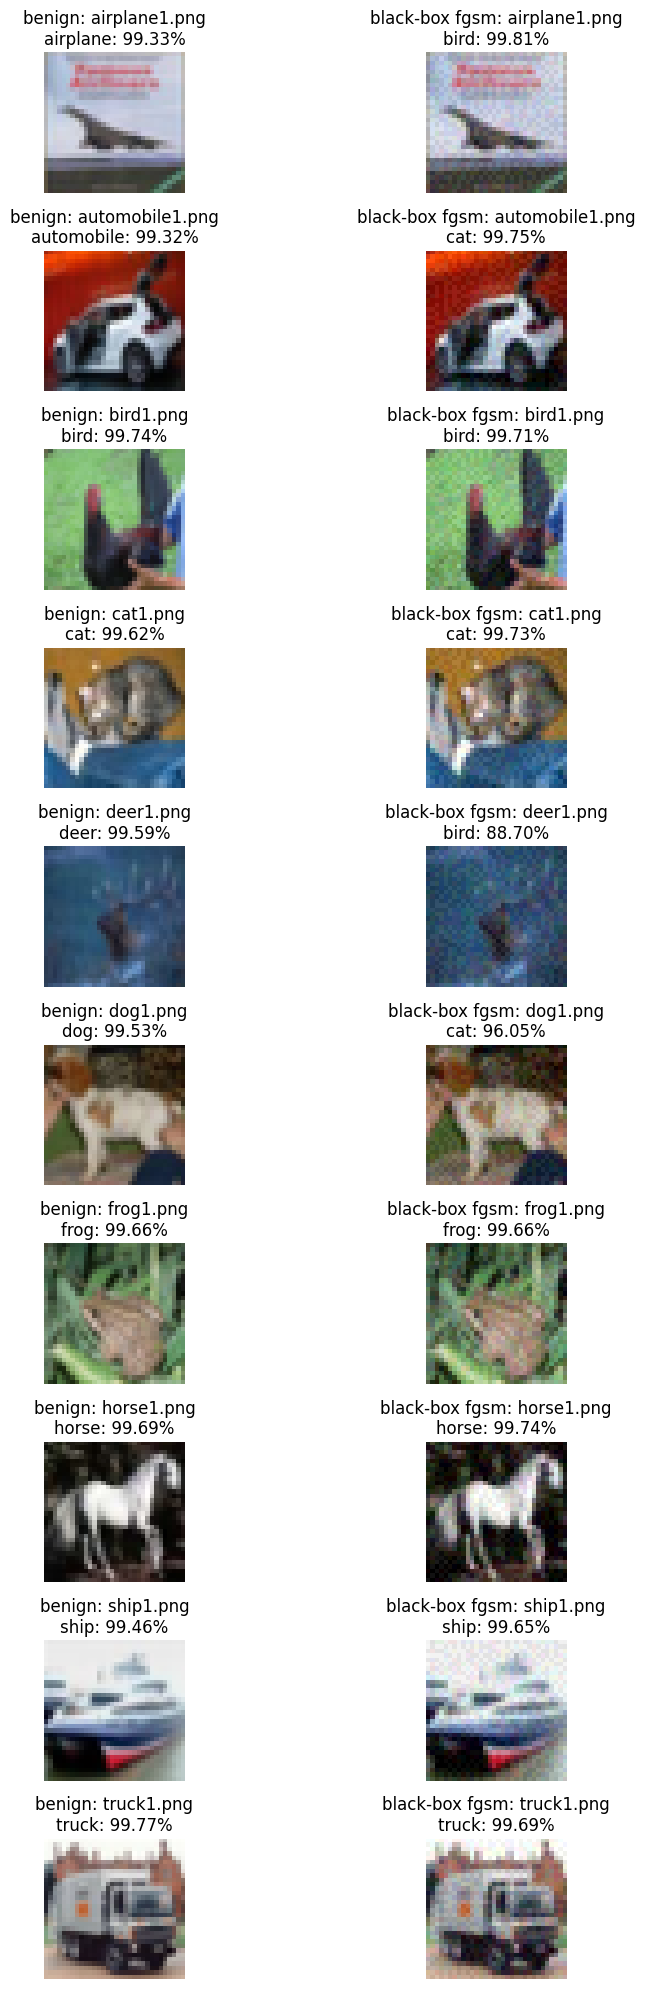

Saved visualization to: /content/drive/MyDrive/Colab Notebooks/Homework/HW4/blackbox_fgsm_visualization.png


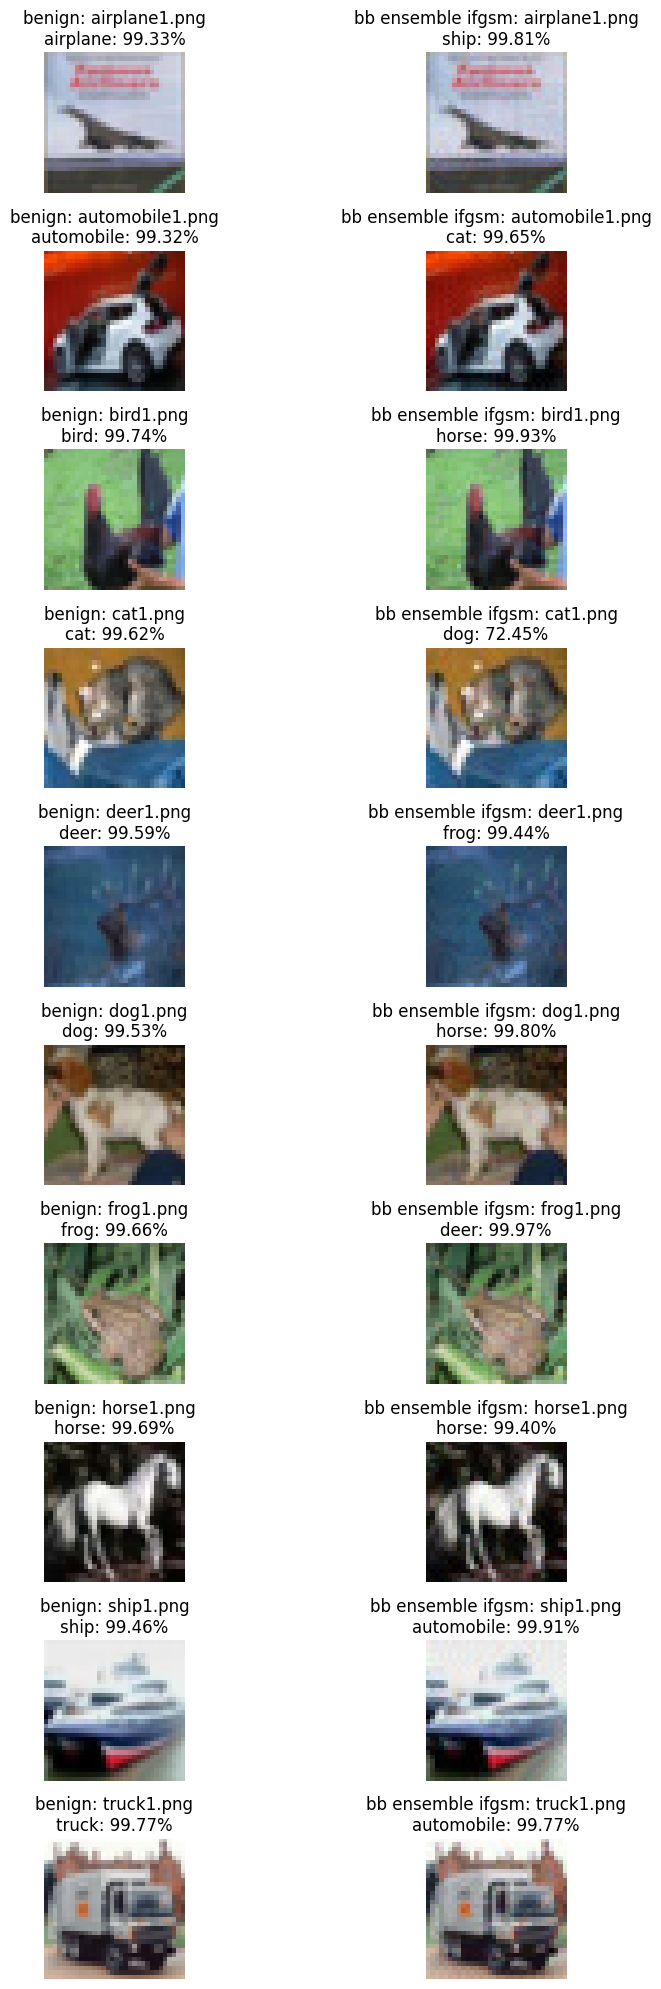

Saved visualization to: /content/drive/MyDrive/Colab Notebooks/Homework/HW4/blackbox_ifgsm_ensemble_visualization.png


In [17]:

def visualize_attack_grid(attack_folder, title_prefix, out_name):
    plt.figure(figsize=(10, 20))
    cnt = 0
    for cls_name in classes:
        path = f'{cls_name}/{cls_name}1.png'

        cnt += 1
        plt.subplot(len(classes), 2, cnt)
        im = Image.open(f'./data/{path}')
        logit = model(transform(im).unsqueeze(0).to(device))[0]
        predict = logit.argmax(-1).item()
        prob = logit.softmax(-1)[predict].item()
        plt.title(f'benign: {cls_name}1.png\n{classes[predict]}: {prob:.2%}')
        plt.axis('off')
        plt.imshow(np.array(im))

        cnt += 1
        plt.subplot(len(classes), 2, cnt)
        im = Image.open(os.path.join(save_root, attack_folder, path))
        logit = model(transform(im).unsqueeze(0).to(device))[0]
        predict = logit.argmax(-1).item()
        prob = logit.softmax(-1)[predict].item()
        plt.title(f'{title_prefix}: {cls_name}1.png\n{classes[predict]}: {prob:.2%}')
        plt.axis('off')
        plt.imshow(np.array(im))

    plt.tight_layout()
    out_path = os.path.join(save_root, out_name)
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved visualization to: {out_path}')

visualize_attack_grid('ifgsm', 'ifgsm', 'ifgsm_visualization.png')
visualize_attack_grid('blackbox_fgsm', 'black-box fgsm', 'blackbox_fgsm_visualization.png')
visualize_attack_grid('blackbox_ifgsm_ensemble', 'bb ensemble ifgsm', 'blackbox_ifgsm_ensemble_visualization.png')
